In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

In [4]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
database = os.getenv("DB_NAME")
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

In [6]:
fact = pd.read_sql("SELECT * FROM fact_sales", engine)
customer = pd.read_sql("SELECT * FROM dim_customer", engine)
product = pd.read_sql("SELECT * FROM dim_product", engine)
date = pd.read_sql("SELECT * FROM dim_date", engine)

In [10]:
df = fact.merge(customer, how='left', on='CustomerID').merge(product, how='left', on = 'StockCode').merge(date, on='DateID', how='left')

In [11]:
df.shape

(386087, 14)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 386087 entries, 0 to 386086
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    386087 non-null  str    
 1   DateID       386087 non-null  int64  
 2   CustomerID   386087 non-null  int64  
 3   StockCode    386087 non-null  str    
 4   Quantity     386087 non-null  int64  
 5   UnitPrice    386087 non-null  float64
 6   TotalPrice   386087 non-null  float64
 7   Country      386087 non-null  str    
 8   Description  386087 non-null  str    
 9   InvoiceDATE  386087 non-null  object 
 10  Year         386087 non-null  int64  
 11  Month        386087 non-null  int64  
 12  Day          386087 non-null  int64  
 13  Weekday      386087 non-null  int64  
dtypes: float64(2), int64(7), object(1), str(4)
memory usage: 41.2+ MB


In [20]:
df.describe()

,DateID,CustomerID,Quantity,UnitPrice,TotalPrice,Year,Month,Day,Weekday
count,3.860870e+05,386087.000000,386087.000000,386087.000000,386087.000000,386087.000000,386087.000000,386087.000000,386087.000000
mean,2.011012e+07,15290.411881,13.252886,2.885936,22.533446,2010.934706,7.591012,15.043337,2.601947
std,2.377062e+03,1710.340332,181.977374,4.306198,312.949669,0.247043,3.414636,8.649074,1.920798
min,2.010120e+07,12346.000000,1.000000,0.040000,0.060000,2010.000000,1.000000,1.000000,0.000000
25%,2.011041e+07,13969.000000,2.000000,1.250000,4.950000,2011.000000,5.000000,7.000000,1.000000
50%,2.011073e+07,15152.000000,6.000000,1.950000,12.480000,2011.000000,8.000000,15.000000,2.000000
75%,2.011102e+07,16791.000000,12.000000,3.750000,19.800000,2011.000000,11.000000,22.000000,4.000000
max,2.011121e+07,18287.000000,80995.000000,649.500000,168469.600000,2011.000000,12.000000,31.000000,6.000000


In [21]:
df.head()

,InvoiceNo,DateID,CustomerID,StockCode,Quantity,UnitPrice,TotalPrice,Country,Description,InvoiceDATE,Year,Month,Day,Weekday
0,536365,20101201,17850,21730,6,4.25,25.50,United Kingdom,GLASS STAR FROSTED T-LIGHT HOLDER,2010-12-01,2010,12,1,2
1,536365,20101201,17850,22752,2,7.65,15.30,United Kingdom,SET 7 BABUSHKA NESTING BOXES,2010-12-01,2010,12,1,2
2,536365,20101201,17850,71053,6,3.39,20.34,United Kingdom,WHITE METAL LANTERN,2010-12-01,2010,12,1,2
3,536365,20101201,17850,84029E,6,3.39,20.34,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,2010-12-01,2010,12,1,2
4,536365,20101201,17850,84029G,6,3.39,20.34,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,2010-12-01,2010,12,1,2


In [22]:
#Total Revenue
df['TotalPrice'].sum()

np.float64(8699870.530000001)

In [ ]:
#Total Orders
df['InvoiceNo'].nunique()

18394

In [ ]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [38]:
plt.style.use('Solarize_Light2')

<Axes: title={'center': 'Sales Over The Time'}, xlabel='InvoiceDATE', ylabel=' Sum of total price in GBP'>

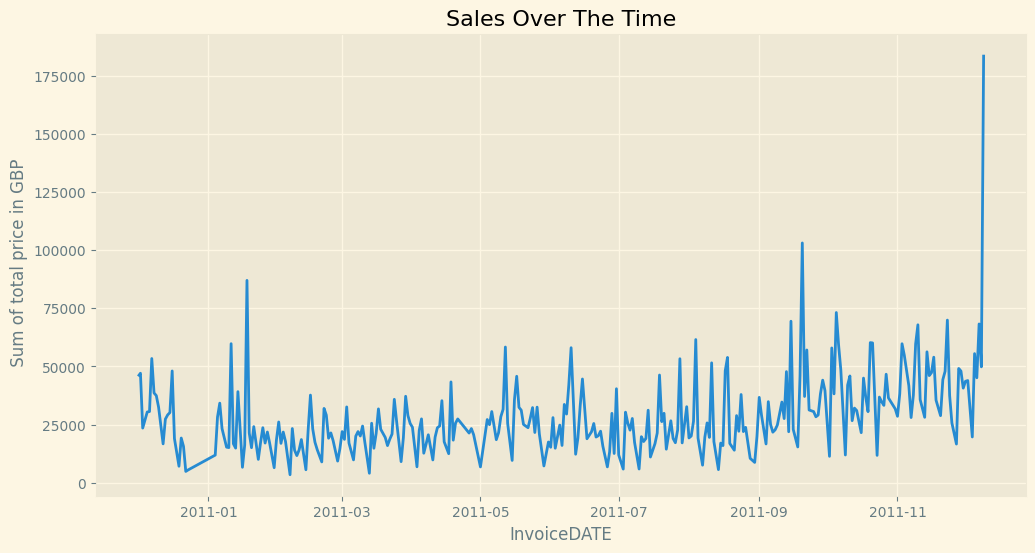

In [48]:
#Sales Over The Time
df.groupby('InvoiceDATE')['TotalPrice'].sum().plot(kind='line', figsize=(12,6), title='Sales Over The Time', ylabel= ' Sum of total price in GBP')

<Axes: title={'center': 'Sales By Country'}, xlabel='Country', ylabel='Sum of Total price in GBP'>

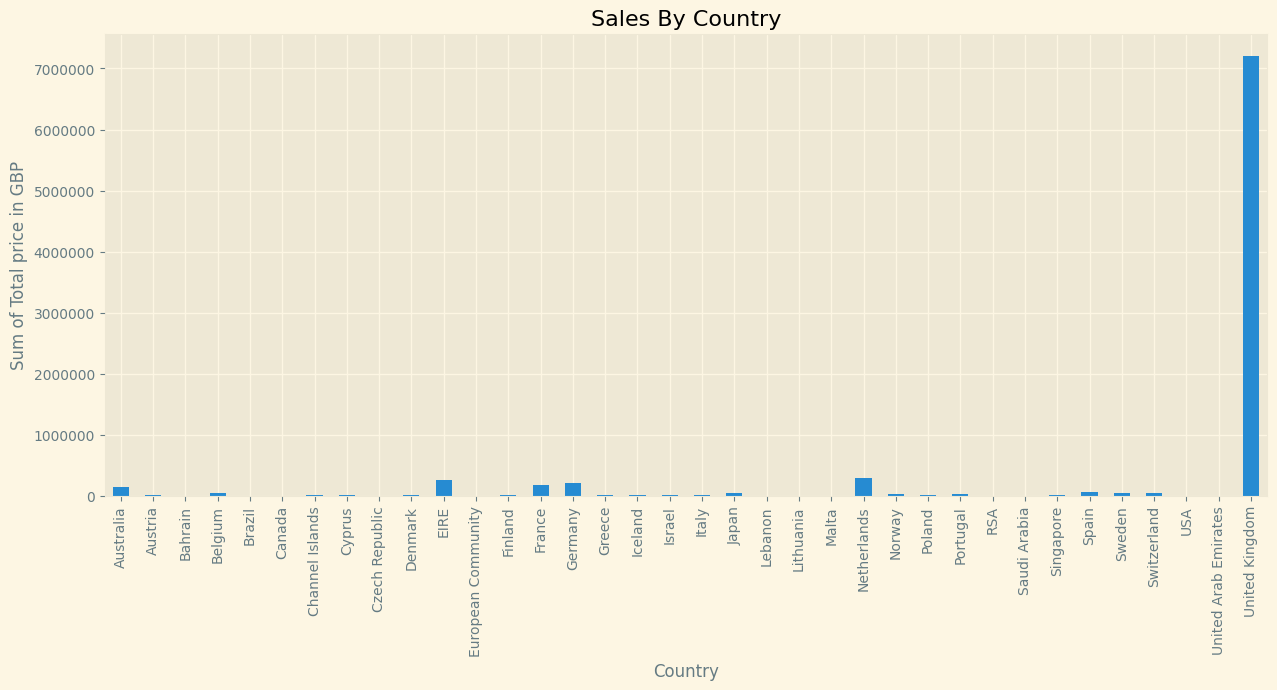

In [63]:
#Sales By Country
plt.gca().ticklabel_format(style='plain', axis='y', useOffset=False)
df.groupby('Country')['TotalPrice'].sum().plot(kind='bar', figsize=(15,6), title='Sales By Country',ylabel= 'Sum of Total price in GBP')

<Axes: title={'center': 'Sales By Country Except From UK'}, xlabel='Country', ylabel='Sum Of Total price in GBP'>

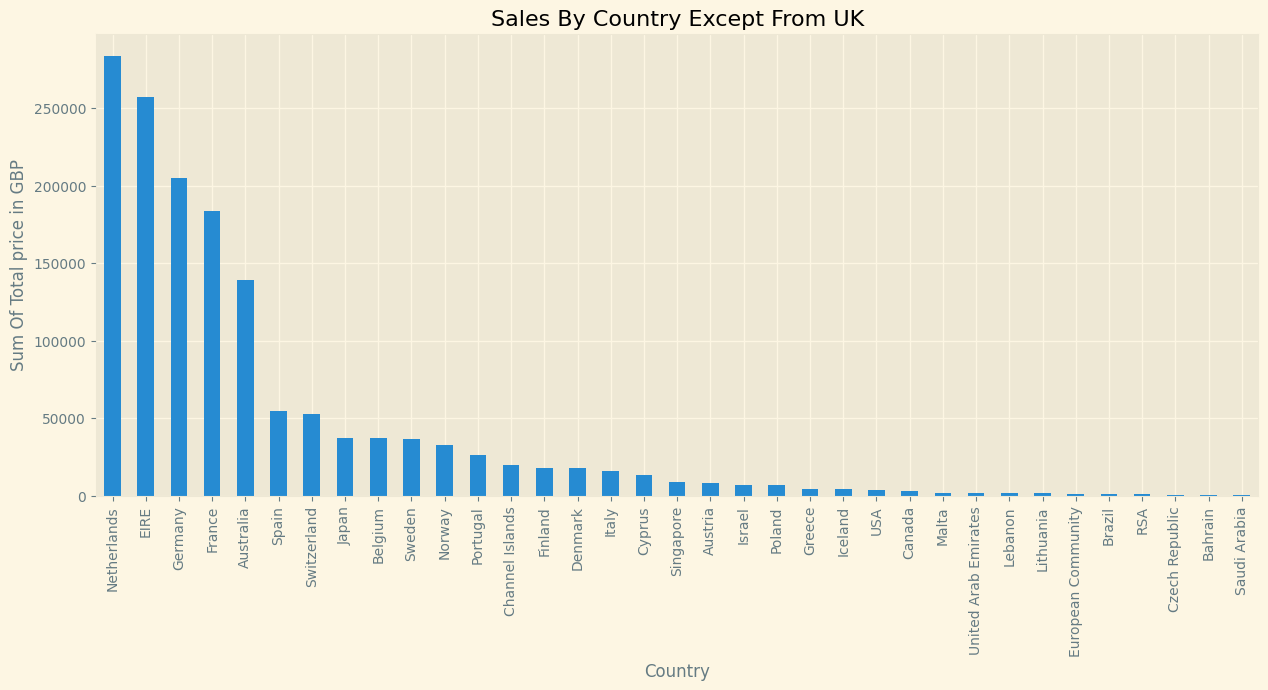

In [62]:
#Sales By Country Except UK
other = df[df['Country'] != 'United Kingdom']
other.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(15,6),title='Sales By Country Except From UK',ylabel='Sum Of Total price in GBP')

<Axes: title={'center': 'Top 10 Products'}, xlabel='Product', ylabel='Sum Of Total Price in GBP'>

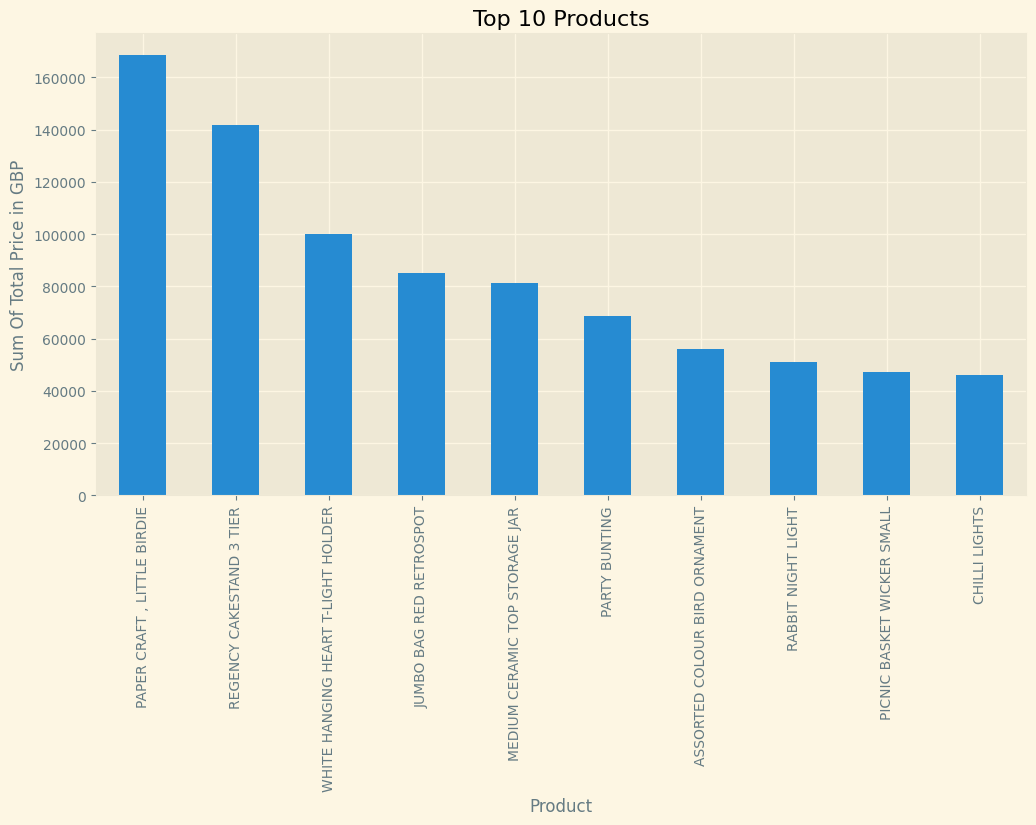

In [61]:
#Top 10 Products
df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6) , title='Top 10 Products', xlabel='Product',ylabel= 'Sum Of Total Price in GBP')

<Axes: title={'center': 'Top 10 Customers'}, xlabel='CustomerID', ylabel='Sum Of Total Price in GBP'>

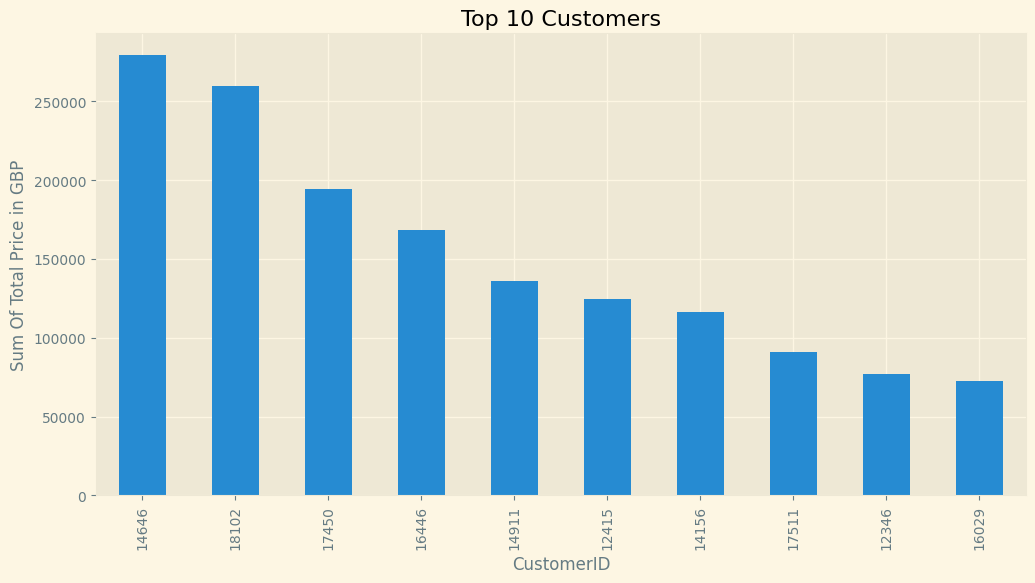

In [67]:
#Top 10 Customers
df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6) , title='Top 10 Customers', xlabel='CustomerID',ylabel= 'Sum Of Total Price in GBP')

<Axes: ylabel='Frequency'>

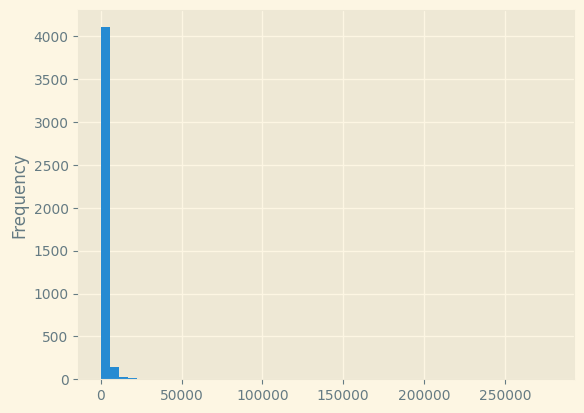

In [81]:
#Customer Distribution
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()
customer_spending.plot(kind='hist', bins=50)
#just a few customers spend lots of money

<Axes: title={'center': 'Monthly Sales'}, xlabel='Month', ylabel='Sum of total price in GBP'>

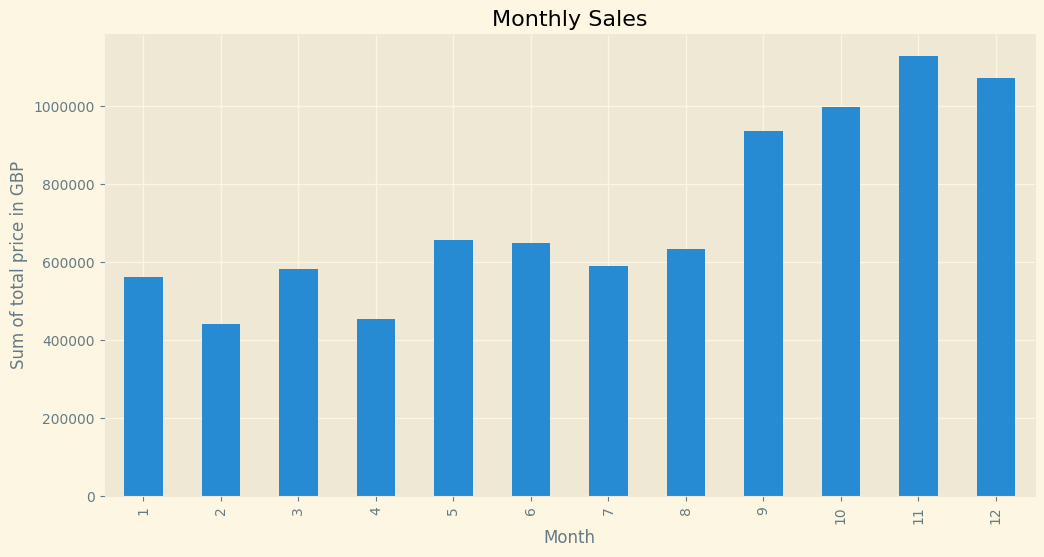

In [85]:
#Monthly Sales
plt.gca().ticklabel_format(style='plain', axis='y', useOffset=False)
df.groupby('Month')['TotalPrice'].sum().plot(kind='bar', figsize=(12,6), title='Monthly Sales', ylabel='Sum of total price in GBP')

In [ ]:
#Average Order Value
df.groupby('InvoiceNo')['TotalPrice'].sum().mean().round(2)

np.float64(472.97)

In [95]:
#Average Items per Order
df.groupby('InvoiceNo')['Quantity'].sum().mean().round(0)

np.float64(278.0)